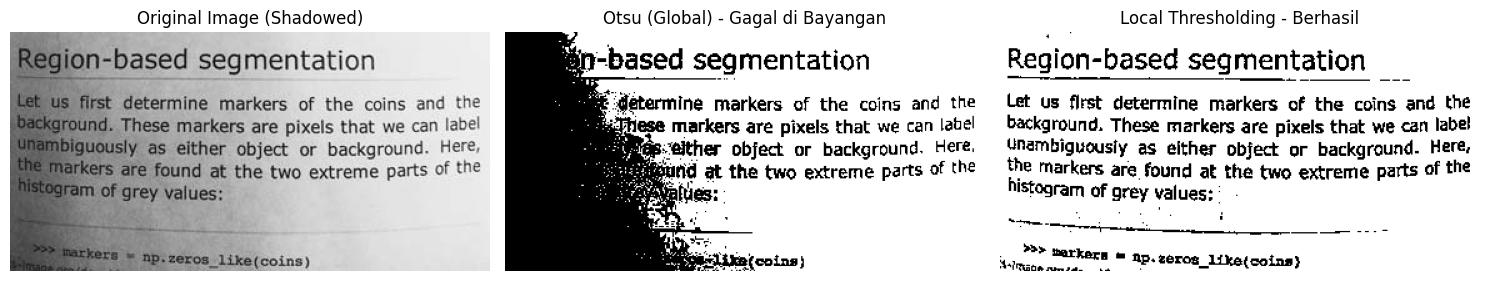

In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

# 1. Memuat citra page (dokumen dengan bayangan)
image_page = data.page()

# 2. Penerapan Otsu Thresholding (Global)
thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# 3. Penerapan Local Thresholding (Adaptive)
# block_size adalah ukuran area sekitar piksel, harus ganjil
# offset membantu memisahkan teks dari latar belakang yang kusam
thresh_local = filters.threshold_local(image_page, block_size=35, offset=10)
binary_local = image_page > thresh_local

# 4. Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax = axes.ravel()

ax[0].imshow(image_page, cmap='gray')
ax[0].set_title('Original Image (Shadowed)')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title('Otsu (Global) - Gagal di Bayangan')
ax[1].axis('off')

ax[2].imshow(binary_local, cmap='gray')
ax[2].set_title('Local Thresholding - Berhasil')
ax[2].axis('off')

plt.tight_layout()
plt.show()

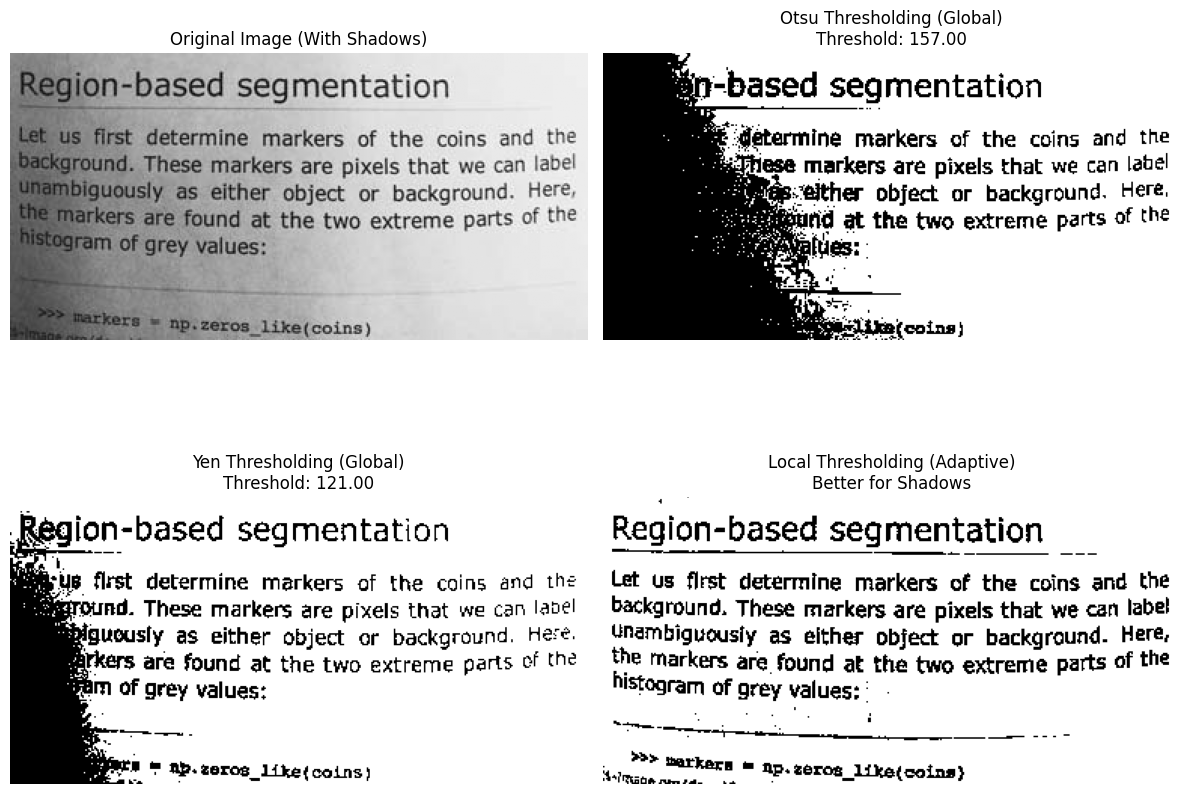

In [2]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.color import rgb2gray

# 1. Memuat citra page (dokumen dengan pencahayaan tidak merata)
image_page = data.page()

# 2. Thresholding Global: Otsu
# Mencari satu ambang batas optimal untuk seluruh citra
thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# 3. Thresholding Global: Yen
# Metode global lain yang sering digunakan untuk citra dengan histogram tertentu
thresh_yen = filters.threshold_yen(image_page)
binary_yen = image_page > thresh_yen

# 4. Thresholding Lokal: Adaptive (threshold_local)
# Menghitung ambang batas untuk setiap piksel berdasarkan area sekitarnya
# block_size: ukuran jendela (harus ganjil), offset: konstanta pengurang
thresh_local = filters.threshold_local(image_page, block_size=35, offset=10)
binary_local = image_page > thresh_local

# 5. Visualisasi Perbandingan
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
ax = axes.ravel()

# Citra Asli
ax[0].imshow(image_page, cmap='gray')
ax[0].set_title('Original Image (With Shadows)')
ax[0].axis('off')

# Hasil Otsu
ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu Thresholding (Global)\nThreshold: {thresh_otsu:.2f}')
ax[1].axis('off')

# Hasil Yen
ax[2].imshow(binary_yen, cmap='gray')
ax[2].set_title(f'Yen Thresholding (Global)\nThreshold: {thresh_yen:.2f}')
ax[2].axis('off')

# Hasil Local
ax[3].imshow(binary_local, cmap='gray')
ax[3].set_title('Local Thresholding (Adaptive)\nBetter for Shadows')
ax[3].axis('off')

plt.tight_layout()
plt.show()

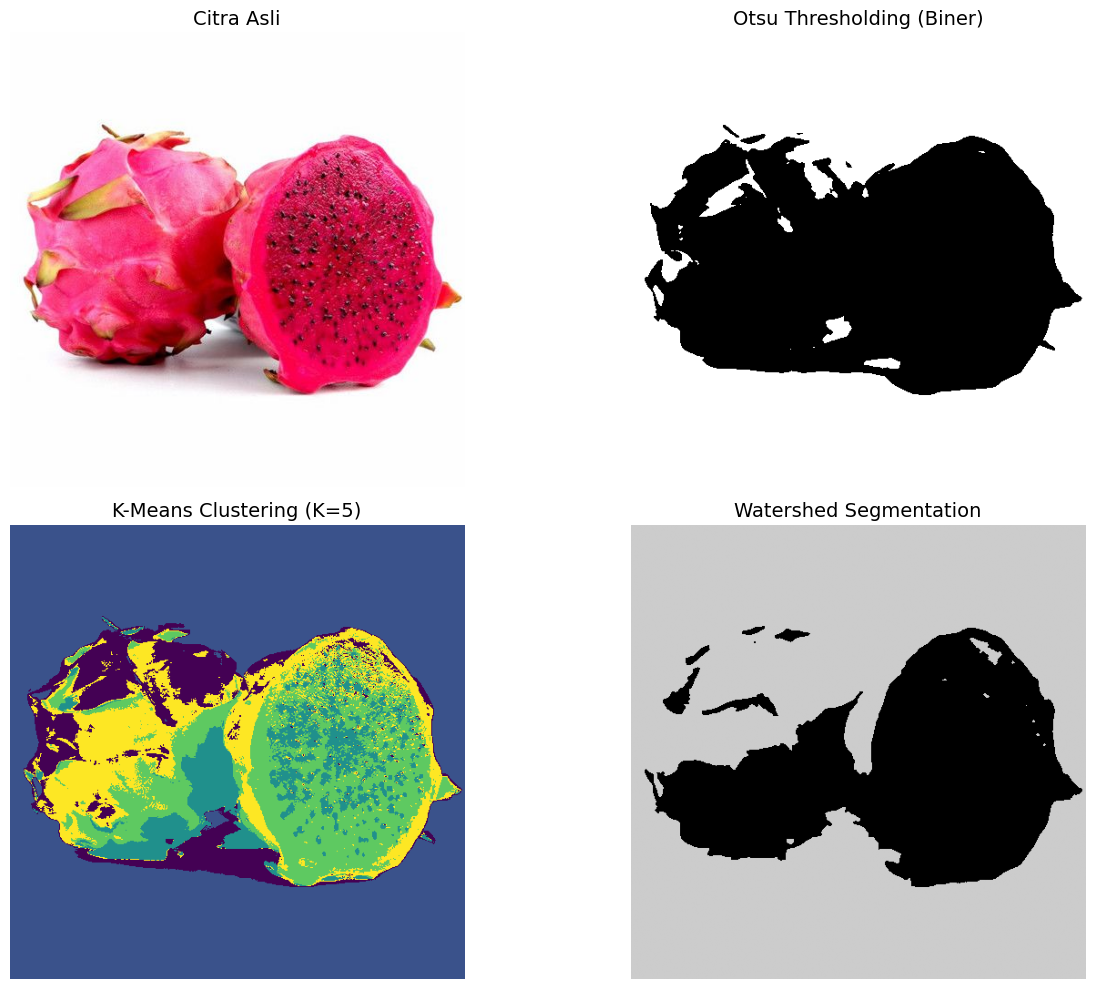

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, segmentation
from sklearn.cluster import KMeans

# 1. Load Citra
# Pastikan file gambar berada di folder yang sama dengan skrip ini
try:
    img = io.imread('buah-naga.jpg')
except FileNotFoundError:
    print("File tidak ditemukan! Pastikan nama file sudah benar.")
    # Jika menggunakan Google Colab, upload file terlebih dahulu.

# Konversi ke Grayscale untuk Otsu & Watershed
gray = color.rgb2gray(img)

# Preprocessing: Denoising dengan Gaussian Filter 
# Membantu menghilangkan noise pada tekstur kain latar belakang
denoised = filters.gaussian(gray, sigma=1)

# --- METODE 1: OTSU THRESHOLDING ---
# Menghitung ambang batas (threshold) otomatis
thresh = filters.threshold_otsu(denoised)
otsu_res = denoised > thresh

# --- METODE 2: K-MEANS CLUSTERING ---
# Reshape citra RGB menjadi list piksel (N piksel x 3 channel warna)
pixels = img.reshape((-1, 3))
# Menggunakan n_init='auto' untuk menghindari warning pada versi library terbaru
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto').fit(pixels)
# Reshape kembali label ke dimensi gambar asli
kmeans_res = kmeans.labels_.reshape(img.shape[:2])

# --- METODE 3: WATERSHED SEGMENTATION ---
# 1. Peta elevasi menggunakan filter Sobel untuk mendeteksi tepi/kontur
elevation_map = filters.sobel(denoised)

# 2. PERBAIKAN: Membuat markers dengan tipe data INTEGER (np.int32)
# Jika menggunakan float, akan menyebabkan TypeError: No matching signature found
markers = np.zeros(gray.shape, dtype=np.int32)

# Tentukan marker berdasarkan intensitas cahaya
# Angka ini mungkin perlu disesuaikan tergantung kecerahan foto kamu
markers[gray < 0.2] = 1  # Background / Area gelap
markers[gray > 0.7] = 2  # Objek / Area terang

# 3. Eksekusi Watershed
watershed_res = segmentation.watershed(elevation_map, markers)

# --- VISUALISASI PERBANDINGAN ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes.ravel()

ax[0].imshow(img)
ax[0].set_title("Citra Asli", fontsize=14)

ax[1].imshow(otsu_res, cmap='gray')
ax[1].set_title("Otsu Thresholding (Biner)", fontsize=14)

# Gunakan colormap 'viridis' atau 'jet' untuk membedakan cluster warna
ax[2].imshow(kmeans_res, cmap='viridis')
ax[2].set_title("K-Means Clustering (K=5)", fontsize=14)

# Gunakan 'nipy_spectral' agar tiap segmen Watershed terlihat kontras
ax[3].imshow(watershed_res, cmap='nipy_spectral')
ax[3].set_title("Watershed Segmentation", fontsize=14)

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()